# Study area selection

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

This notebook contains the code for selecting the study area for the Random Forest analysis of factors influencing post-fire vegetation recovery in tropical peat forests in Indonesia. With the island of Kalimantan as the general study area, in this notebook we identify the specific pixels for which we want to analyze recovery. This selection is composed of the following steps:
1. [Delimit geographic boundaries](#Geographic-boundaries)
2. [Use MODIS fire alerts to identify study period](#MODIS-fire-alerts)
3. [Load burned area](#Burned-area)
4. [Filter for peatland area](#Peatlands)
5. [Remove area that burned again](#Burned-again)
6. [Filter for area that was forest pre-fire](#Forest-2015)
7. [Remove area that was converted to cropland](#Cropland-2021)

At the end, a TIFF file with the pixels used for our investigation is exported

In [1]:
# defined start and end of fire season we investigate
start_date = '2015-08-01'
end_date = '2015-10-31'

In [2]:
import xarray as xr
import rioxarray as rxr
from rasterio.enums import Resampling
import numpy as np
import os
from rioxarray.merge import merge_arrays
import geopandas as gpd
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
from shapely.geometry import MultiPolygon

In [3]:
# load custom function from custom_functions.py
from custom_functions import sel_bounds 

# Geographic boundaries

In [4]:
# import country borders using natural earth data
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
world = gpd.read_file(shpfilename)

# select only Indonesia
indonesia = world[world['NAME'] == 'Indonesia']

# export
indonesia.to_file('output-data/borders/indonesia.shp')

In [5]:
# extract islands

# split MultiPolygon into individual polygons
islands = indonesia.explode(index_parts=True).reset_index(drop=True)

# add area (in degrees² — good enough for sorting/filtering)
islands['area'] = islands.geometry.area

# sort by area descending
islands_sorted = islands.sort_values('area', ascending=False).reset_index(drop=True)

# extract by rank
kalimantan = islands_sorted.iloc[[0]]
sumatra = islands_sorted.iloc[[1]]
papua = islands_sorted.iloc[[2]]

# export
kalimantan.to_file('output-data/borders/kalimantan.shp')
sumatra.to_file('output-data/borders/sumatra.shp')
papua.to_file('output-data/borders/papua.shp')


/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_948/774798125.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  islands['area'] = islands.geometry.area


<Axes: >

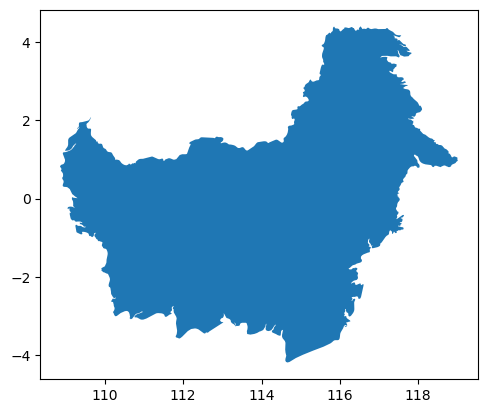

In [6]:
kalimantan.plot()

In [7]:
# get bounding box coordinates
kalimantan.bounds

,minx,miny,maxx,maxy
0,108.855479,-4.184177,119.011729,4.396787


# MODIS fire alerts 
from NASA FIRMS

Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

$\rightarrow$ used to identify study period (which fire season) and as influencing factor (fire history)

In [8]:
# read as geopandas dataframe
modis_fa = gpd.read_file("input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp")

In [9]:
# filter to only keep TYPE 0 (presumed vegetation fire, not volcano activity etc.)
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0].copy()

In [10]:
# add column with year and month (as integers)
modis_fa_vf.loc[:,"YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

modis_fa_vf.loc[:,"MONTH"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=2).str[1].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

In [11]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,YEAR,MONTH
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),2001,1
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),2001,1
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),2001,1
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),2001,1
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),2001,1


Number of fire pixels in 2015: 2810394


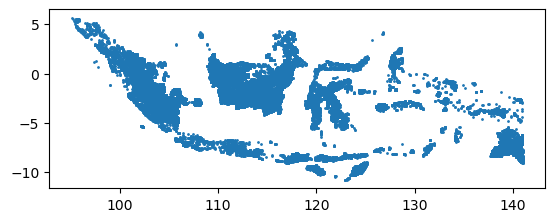

In [12]:
# plot fires in 2015
modis_fa_vf_2015 = modis_fa_vf[modis_fa_vf["YEAR"] == 2015]

print("Number of fire pixels in 2015:", end=' ')
print(modis_fa_vf_2015.size)

modis_fa_vf_2015.plot(markersize=1)
plt.show()

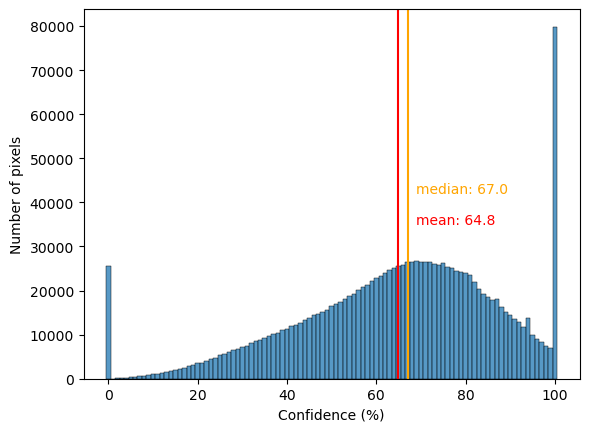

In [13]:
# check distribution of confidence
sns.histplot(x="CONFIDENCE", data=modis_fa_vf, discrete=True)
plt.ylabel("Number of pixels")
plt.xlabel("Confidence (%)")

# add mean confidence
mean_conf = modis_fa_vf.CONFIDENCE.mean()
plt.axvline(mean_conf, color="red")
plt.text(x=mean_conf+4, y=35000, s=f"mean: {round(mean_conf,1)}", color="red")

# add median confidence
med_conf = np.median(modis_fa_vf.CONFIDENCE)
plt.axvline(med_conf, color="orange")
plt.text(x=mean_conf+4, y=42000, s=f"median: {round(med_conf,1)}", color="orange")

plt.show()

In [14]:
np.std(modis_fa_vf.CONFIDENCE)

22.252626195361497

In [15]:
# add boolean column with confidence classification based on defined threshold
confidence_threshold = 70
modis_fa_vf['HIGH_CONFIDENCE'] = np.where(modis_fa_vf['CONFIDENCE'] >= confidence_threshold, True, False)

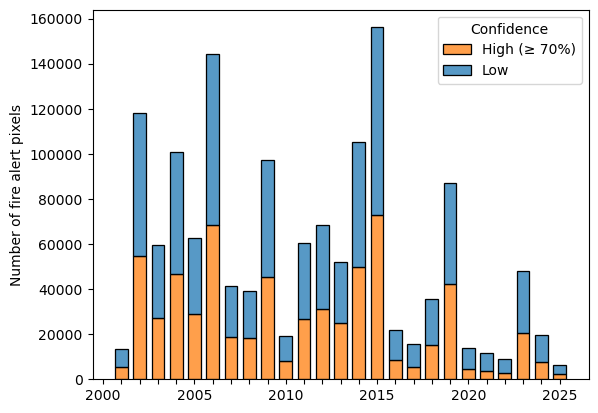

In [16]:
# check nr of fires per year
sns.histplot(x="YEAR", 
             hue="HIGH_CONFIDENCE", multiple="stack", 
             legend=False,
             data=modis_fa_vf,
             discrete=True,
             shrink=.7)

# adjust xticks
values = np.arange(2000,2026,1)
labels = np.arange(2000,2026,1)[::5] # only every fifth
labels = np.where(np.isin(values, labels), values, "")
plt.xticks(values, labels=labels)

plt.xlabel("")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

$\rightarrow$ 2015 was the year with the most fire alerts

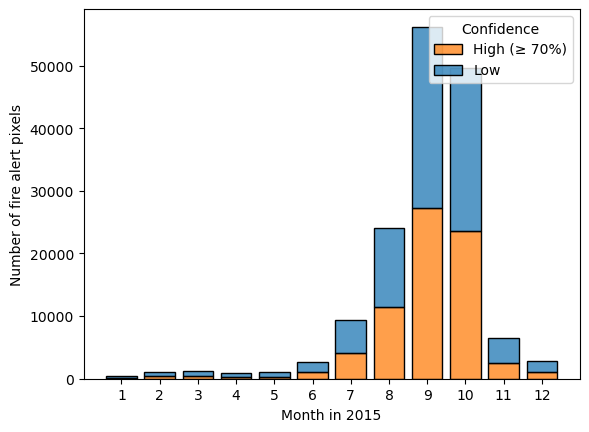

In [17]:
# check fires per month in 2015
modis_fa_2015 = modis_fa_vf[modis_fa_vf.YEAR == 2015]

sns.histplot(x="MONTH", 
             hue="HIGH_CONFIDENCE",
             multiple="stack", discrete=True,
             legend=False,
             shrink=.8,
             data=modis_fa_2015)

plt.xticks(np.arange(1,13,1))

plt.xlabel("Month in 2015")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

most fires from August to October $\rightarrow$ investigate recovery from fires in this time interval

In [18]:
# keep only relevant columns
modis_fa_vf = modis_fa_vf[['LATITUDE', 'LONGITUDE', 'ACQ_DATE', 'CONFIDENCE', 'geometry', 'HIGH_CONFIDENCE']]

In [19]:
# subset to before, during, and after fire detection period (high confidence only)
# lower confidence threshold for after 2015 to make sure to exclude pixels with repeated burns

fires_before = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= confidence_threshold) & (modis_fa_vf.ACQ_DATE < start_date)]
fires_summer_2015 = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= confidence_threshold) & (modis_fa_vf.ACQ_DATE.between(start_date,end_date))]
fires_after = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= 30) & (modis_fa_vf.ACQ_DATE > end_date) & (modis_fa_vf.ACQ_DATE < '2022-01-01')]

In [20]:
# export 
fires_before.to_file('output-data/fire-alerts/fire_alerts_before.shp')
fires_after.to_file('output-data/fire-alerts/fire_alerts_after.shp')
fires_summer_2015.to_file('output-data/fire-alerts/fire_alerts_summer_2015.shp')

/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_948/485468498.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fires_before.to_file('output-data/fire-alerts/fire_alerts_before.shp')
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ACQ_DATE created as String field, though DateTime requested.
  ogr_write(
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'HIGH_CONFIDENCE' to 'HIGH_CONFI'
  ogr_write(
/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_948/485468498.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fires_after.to_file('output-data/fire-alerts/fire_alerts_after.shp')
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ACQ_DATE created as 

continued in [here](#Fire-history)

# Burned area

created with GEE (see `GEE_script.js`)
using this dataset: https://developers.google.com/earth-engine/datasets/catalog/ESA_CCI_FireCCI_5_1

already filtered temporally from Aug 1 to Oct 31 2015

In [21]:
import rioxarray as rxr
import rasterio 
import numpy as np

In [22]:
# load file
burned_area = rxr.open_rasterio("input-data/MODIS-exports/FireCCI_2015.tif")

In [23]:
burned_area

<xarray.DataArray (band: 4, y: 3825, x: 4721)> Size: 144MB
[72231300 values with dtype=int16]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 31kB 4.369 4.367 4.365 ... -4.214 -4.216 -4.219
  * x            (x) float64 38kB 108.5 108.5 108.5 108.5 ... 119.1 119.1 119.1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('BurnDate', 'ConfidenceLevel', 'LandCover', 'ObservedFlag')

In [24]:
burned_area.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [25]:
burned_area.rio.resolution()

(0.002245788210298804, -0.002245788210298804)

In [26]:
# split up into layers (keep only x and y dimensions)

# band 1 contains day of the year when fire was first detected
# 0 means no fire detected
burn_doy = burned_area.sel(band=1)

# band 2 contains the confidence 
burn_conf = burned_area.sel(band=2)

# band 4 contains flags: -2 (unburnable), -1 (not observed)
burn_flag = burned_area.sel(band=4)

In [27]:
# make burn binary
burned_2015 = xr.where(burn_doy > 0, 1, 0)

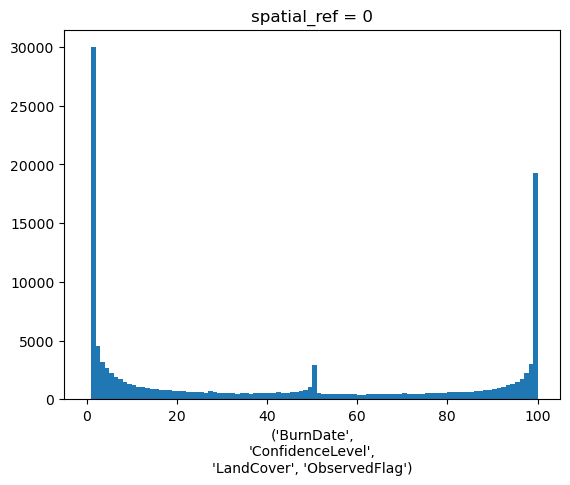

In [28]:
# check confidence distribution
burned_conf = burn_conf.where(burned_2015 == 1) # only in actually burned pixels
burned_conf.plot.hist(bins=np.arange(0,101,1))
plt.show()

In [29]:
# quality control - keep only high confidence burns and remove pixels with flags
# set other pixels that don't fulfill condition to 0
# ascribe CRS again (gets lost through condition)
burned_2015_clean = burned_2015.where((burn_conf > 40) & (burn_flag == 0), other=0).rio.write_crs(4326)

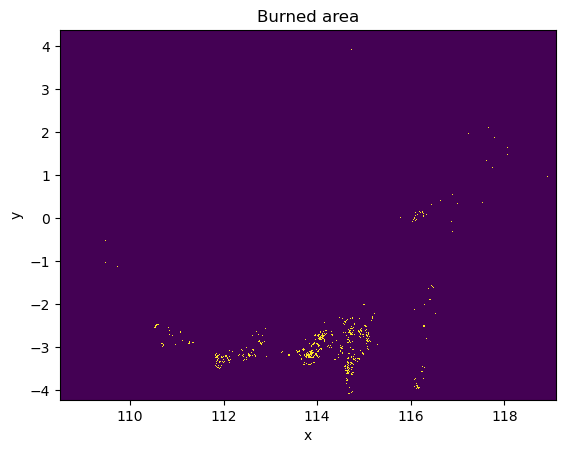

In [30]:
burned_2015_clean.plot(add_colorbar=False)
plt.title('Burned area')
plt.show()

$\rightarrow$ this burned area raster (EPSG 4326 and 250m resolution) will serve as the reference raster that all other rasters will be reprojected to and aligned with

# Peatlands

from Global Peatlands

In [31]:
# load data as xarray (squeeze removes band as dimension)
peatland_global = rxr.open_rasterio("input-data/global-peatland-map/peatGPA22WGS_2cl.tif").squeeze()

# set CRS
peatland_global.rio.write_crs(4326, inplace=True)

# subset to study area
peatland = sel_bounds(peatland_global, burned_2015_clean)

In [32]:
# make binary: set 255 (no peatland) and 2 (peat in soil matrix) to 0
peatland = peatland.where(peatland == 1, other=0).astype('uint8')

In [33]:
# reproject to match burned area projection/resolution/grid
peatland_reproj = peatland.rio.reproject_match(
    burned_2015_clean, 
    resampling=Resampling.nearest) # downscaling (1km -> 250m) -> inherit value of larger pixel

# replace resulting 255 values
peatland_reproj = peatland_reproj.where(peatland_reproj != 255, other=0).rio.write_crs(4326)

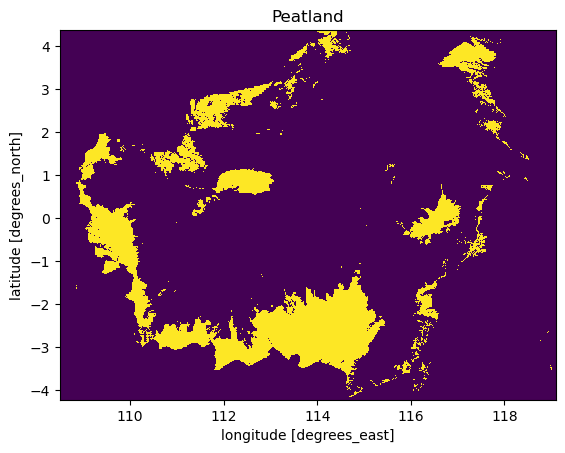

In [34]:
# plot
peatland_reproj.plot(add_colorbar=False)
plt.title('Peatland')
plt.show()

In [35]:
# merge both arrays
merged_study_area = xr.merge([burned_2015_clean.rename('burned_area'),
                              peatland_reproj.rename('peatland')],
                             compat='no_conflicts')

# set up layer that will identify the study area (binary)
merged_study_area['study_area'] = xr.where(
    (merged_study_area.burned_area == 1) & (merged_study_area.peatland == 1), # only areas in peatlands that burned
    1, 0).astype('uint8')

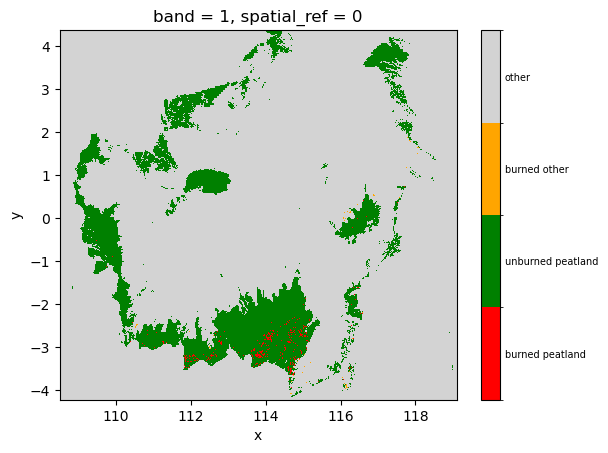

In [116]:
# check where burned area and peatlands overlap

# create array with categories
categories = ['burned peatland', 'unburned peatland', 'burned other', 'other']
burned_peat_categories = xr.where((merged_study_area.burned_area == 1) & (merged_study_area.peatland == 1), 
                                   1, 
                                   xr.where((merged_study_area.burned_area == 0) & (merged_study_area.peatland == 1),
                                            2,
                                            xr.where((merged_study_area.burned_area == 1) & (merged_study_area.peatland != 1),
                                                     3,
                                                     4
                                                     )))

# set up labels and colors
levels = [1,2,3,4]
levels += [levels[-1] + 1]
colors = ['red','green','orange','lightgrey']
labels = categories

# plot classification as a map with a colormap
plt.figure()
ax = burned_peat_categories.plot(levels=levels, colors=colors)

# Compute position of ticks for labeling of colormap
tick_positions = np.mean([levels[:-1], levels[1:]], axis=0)

# Set labels at the middle of each color block in colormap legend 
ax.colorbar.set_ticks(tick_positions)  # define ticks for label position
ax.colorbar.ax.tick_params(length=0)  # hides ticks, so only labels are shown
ax.colorbar.set_ticklabels(labels, fontsize=7) # labels positiond to corresponding color

plt.title('Peatland and burned area combinations')
plt.show()

# Burned again

In [36]:
# Next, rasterize fire alerts with buffer, since points represent centroid of 1km2 pixel that contained fire

# Project to metric CRS (e.g. World Mercator)
fires_proj = fires_after.to_crs("EPSG:3857")

# Buffer 500 meters
fires_proj["geometry"] = fires_proj.buffer(500, cap_style='square') # add 500m buffer

# to target CRS
fires_buffered = fires_proj.to_crs(merged_study_area.rio.crs)

# rasterize to existing study area grid
from rasterio import features

transform = merged_study_area.rio.transform()
out_shape = merged_study_area.rio.shape

shapes = ((geom, 1) for geom in fires_buffered.geometry)

# binary classification
reburn_binary = features.rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    all_touched=True, # as soon as at least one overlap, flag as "burned again"
    dtype="uint8"
)

In [37]:
# add to merged ds
merged_study_area["burned_again"] = xr.DataArray(
    reburn_binary,
    dims=["y", "x"],
    coords={"y": merged_study_area.y, "x": merged_study_area.x},
)

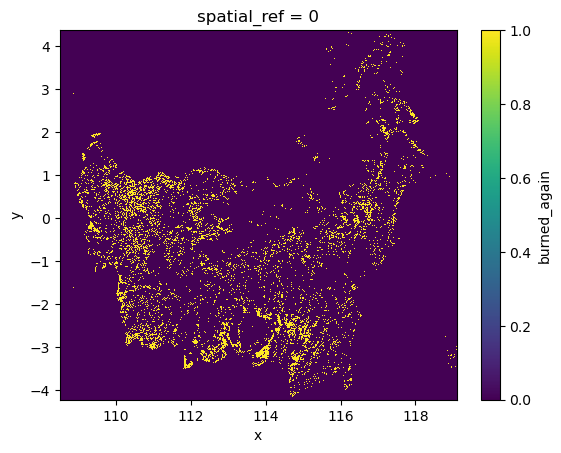

In [129]:
merged_study_area.burned_again.plot()

In [38]:
# update study area (only keep pixels that did not burn again)
merged_study_area['study_area'] = xr.where((merged_study_area.study_area == 1) & (merged_study_area.burned_again == 1),
                                           0, # set to 0 if previously study area but burned again
                                           merged_study_area.study_area) # leave remaining pixels as they are

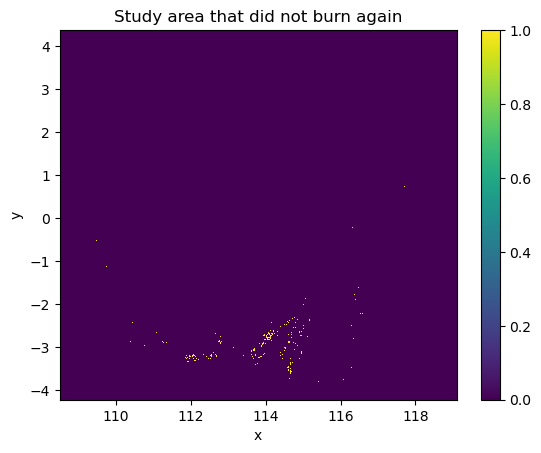

In [121]:
xr.where((merged_study_area.burned_again == 0) & (merged_study_area.study_area == 1), 1, 0).plot()
plt.title('Study area that did not burn again')
plt.show()

# Forest 2015

from Global Landcover map 2015 by Li et al. (2023)

used to identify forest peatland (we only want to study vegetation recovery in burned forest)

In [39]:
# build virtual raster (VRT) to assemble tiles
!gdalbuildvrt input-data/land-cover/landcover_2015_30m.vrt $(find input-data/land-cover -name "*.tif")

0...10...20...30...40...50...60...70...80...90...100 - done.


In [40]:
# load VRT
land_cover_2015_global = rxr.open_rasterio('input-data/land-cover/landcover_2015_30m.vrt')

# crop to study area
land_cover_2015 = sel_bounds(land_cover_2015_global, merged_study_area)

# reclassify to make forest binary
forest_code = 20
forest_2015 = xr.where(land_cover_2015 == forest_code, 1, 0).astype('uint8').rio.write_crs(4326)

# reproject
forest_2015_reproj = forest_2015.rio.reproject_match(
    merged_study_area,
    resampling=Resampling.mode) # majority vote for coarsening (from 30 to 250 m resolution)

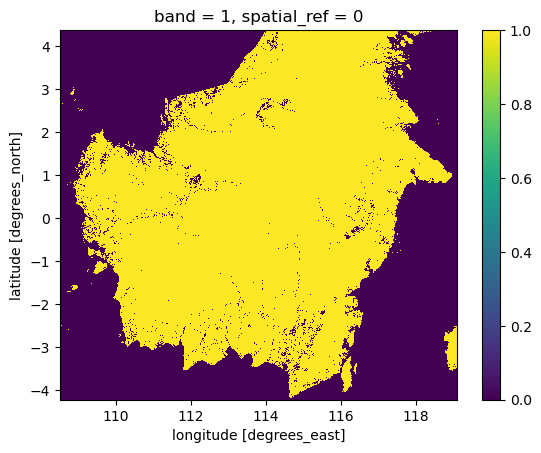

In [128]:
forest_2015_reproj.plot()

In [41]:
# add to merged array
merged_study_area = xr.merge([merged_study_area, 
                              forest_2015_reproj.rename('forest_2015')], 
                             compat='no_conflicts')

# update study area (only where there was forest in 2015)
merged_study_area['study_area'] = xr.where(
    (merged_study_area.study_area == 1) & (merged_study_area.forest_2015 == 0),
    0, # set to 0 if pixel was not forest in 2015
    merged_study_area.study_area) # leave remaining pixels as they are

In [91]:
# export as tif
# merged_study_area.forest_2015.rio.to_raster('output-data/forest/kalimantan_forest_2015.tif')

# Cropland 2021

from ESA WorldCover V2 2021

$\rightarrow$ to filter out areas that were converted to cropland

due to size of data, first build virtual raster of land cover tiles using bash:

In [42]:
!gdalbuildvrt input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt $(find input-data/ESA_IndonesiaCover -name "*.tif")

0...10...20...30...40...50...60...70...80...90...100 - done.


In [54]:
# open VRT (lazily with chunks, to reduce computational demand)
landcover_2021_10m_global = rxr.open_rasterio(
    "input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt",
    chunks={'x':1024, 'y':1024}
)

# crop to study area
landcover_2021_10m = sel_bounds(landcover_2021_10m_global, merged_study_area)

# binary mask (cropland = 1, other = 0)
cropland_code = 40
cropland_2021 = xr.where(landcover_2021_10m == cropland_code, 1, 0).astype("uint8").rio.write_crs(4326)

# reproject
cropland_2021_reproj = cropland_2021.rio.reproject_match(
    merged_study_area,
    resampling=Resampling.max) # if any 10m pixel in the target 250m pixel is cropland(==1), set to 1

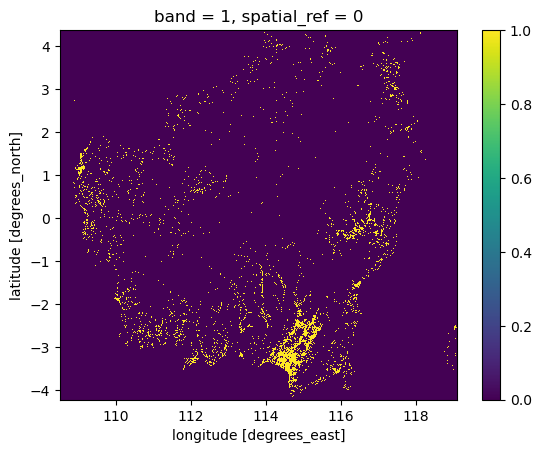

In [55]:
cropland_2021_reproj.plot()

In [56]:
# add to merged array
merged_study_area = xr.merge([merged_study_area, 
                              cropland_2021_reproj.rename('cropland_2021')], 
                             compat='no_conflicts')

# update study area (only where there was NO cropland in 2021)
merged_study_area['study_area'] = xr.where(
    (merged_study_area.study_area == 1) & (merged_study_area.cropland_2021 == 1),
    0, # set to 0 if pixel was converted to cropland by 2021
    merged_study_area.study_area) # leave remaining pixels as they are

# Final study area

In [61]:
# remove band
merged_study_area = merged_study_area.squeeze()

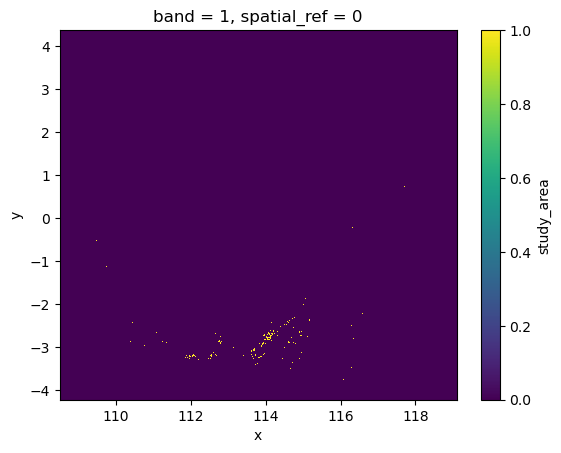

In [57]:
merged_study_area.study_area.plot()

In [62]:
# load Malaysia shapefile to remove unwanted pixels (since Borneo is split between countries, 
# with Kalimantan being the Indonesian part)

malaysia = world[world['NAME'] == 'Malaysia']

# Build a boolean mask: True = inside Malaysia
from rasterio.features import geometry_mask
from shapely.geometry import mapping

geometries = [mapping(geom) for geom in malaysia.geometry]

mask = geometry_mask(
    geometries,
    transform=merged_study_area.rio.transform(),
    invert=True,              # True = pixels inside the shapes
    out_shape=(merged_study_area.rio.height, merged_study_area.rio.width)
)

# Apply: set pixels inside the Malaysia to 0
merged_study_area = merged_study_area.where(~mask, other=0)  # where mask is False (outside), keep original

# Study area

In [66]:
# calculate area

# convert CRS to projection true to area (Equal Earth projection)
study_area_proj = merged_study_area.study_area.rio.reproject(8857)

# remove 255
study_area_proj = xr.where(study_area_proj == 1, 1, 0)

# count pixels
total_study_area_pixels = study_area_proj.sum().item()

# obtain pixel size in m2
res_x, res_y = study_area_proj.rio.resolution()
pixel_area = np.abs(res_x * res_y)

# calculate total area
total_study_area_km2 = (total_study_area_pixels * pixel_area) / 1e6

# fraction of total area
total_area_kalimantan_km2 = 534698.27 # Wikipedia
fraction_kalimantan = total_study_area_km2 / total_area_kalimantan_km2

print(f'Total area identified as study area in Kalimantan: {round(total_study_area_km2)} km2')
print(f'That is equal to {fraction_kalimantan * 100} % of the total area of Kalimantan')

Total area identified as study area in Kalimantan: 1116 km2
That is equal to 0.20869863820238652 % of the total area of Kalimantan


# Export

In [67]:
merged_study_area.study_area.rio.to_raster('output-data/study-area/study_area.tif')

In [68]:
merged_study_area.to_netcdf('output-data/study-area/study-area-all-layers.nc')